# 03 - Feature Engineering Experiments

This notebook experiments with different feature engineering approaches to improve gesture recognition.

## Features to Explore
1. **Velocity** - Frame-to-frame position changes
2. **Acceleration** - Rate of velocity change
3. **Finger Angles** - Angles at finger joints
4. **Hand Bounding Box** - Size and aspect ratio for distance awareness
5. **Relative Positions** - Fingertip positions relative to wrist/palm

In [25]:
# Imports
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


# Add src to path
sys.path.insert(0, str(Path.cwd().parent / 'src'))

from handflow.features import FeatureEngineer
from handflow.utils import load_config

from handflow.data.loader import (
    get_config_hash,
    load_raw_data,
    save_processed_data,
)

plt.style.use('seaborn-v0_8-whitegrid')
print("✅ Imports loaded")

✅ Imports loaded


In [46]:
#Data paths
DATA_PATH = Path('../data/raw/right_mp_Data')
if not DATA_PATH.exists():
    DATA_PATH = Path('../ModelTraining/MP_Data')

ACTIONS = ['none', 'horizontal_swipe', 'zoom', 'pointyclick', 'middleclick', 'swipeup', 'swipedown', 'thumb_left', 'thumb_right', 'touch', 'touch_hold', 'touch_hover']
print(f"📁 Data path: {DATA_PATH}")
print(f"🎯 Actions: {ACTIONS}")

📁 Data path: ../data/raw/right_mp_Data
🎯 Actions: ['none', 'horizontal_swipe', 'zoom', 'pointyclick', 'middleclick', 'swipeup', 'swipedown', 'thumb_left', 'thumb_right', 'touch', 'touch_hold', 'touch_hover']


In [51]:
from pathlib import Path
import numpy as np

def load_raw_data(
    data_path,
    actions,
    sequence_length=12,
    sequences_per_class=50,
):
    """
    Load raw data with a fixed number of sequences per class.

    Returns:
        sequences: (N, T, F)
        labels:    (N,) integer class ids
        label_map: dict[str, int]
    """

    data_path = Path(data_path)
    sequences = []
    labels = []

    label_map = {action: i for i, action in enumerate(actions)}

    for action in actions:
        action_path = data_path / action
        if not action_path.exists():
            print(f"⚠️ Missing: {action_path}")
            continue

        seq_dirs = sorted(d for d in action_path.iterdir() if d.is_dir())
        loaded = 0

        for seq_dir in seq_dirs:
            if loaded >= sequences_per_class:
                break

            window = []
            for frame_num in range(sequence_length):
                frame_path = seq_dir / f"{frame_num}.npy"
                if not frame_path.exists():
                    break
                window.append(np.load(frame_path))

            if len(window) == sequence_length:
                sequences.append(window)
                labels.append(label_map[action])
                loaded += 1

        print(f"✅ Loaded {loaded}/{sequences_per_class} sequences for '{action}'")

    return np.asarray(sequences), np.asarray(labels), label_map


In [52]:
sequences, labels, label_map = load_raw_data(
    DATA_PATH,
    ACTIONS,
    sequence_length=12,
    sequences_per_class=50
)

print(sequences.shape)  # (num_classes * 50, 12, 84)


✅ Loaded 50/50 sequences for 'none'
✅ Loaded 50/50 sequences for 'horizontal_swipe'
✅ Loaded 50/50 sequences for 'zoom'
✅ Loaded 50/50 sequences for 'pointyclick'
✅ Loaded 50/50 sequences for 'middleclick'
✅ Loaded 50/50 sequences for 'swipeup'
✅ Loaded 50/50 sequences for 'swipedown'
✅ Loaded 50/50 sequences for 'thumb_left'
✅ Loaded 50/50 sequences for 'thumb_right'
✅ Loaded 50/50 sequences for 'touch'
✅ Loaded 50/50 sequences for 'touch_hold'
✅ Loaded 50/50 sequences for 'touch_hover'
(600, 12, 84)


In [ ]:
# Create gesture samples dictionary for visualization
# Pick one sample per gesture class for plotting
inverse_label_map = {v: k for k, v in label_map.items()}
gesture_samples = {}

for label_id in np.unique(labels):
    gesture_name = inverse_label_map[label_id]
    # Get first sequence for this label
    idx = np.where(labels == label_id)[0][0]
    gesture_samples[gesture_name] = sequences[idx]

print(f"✅ Created gesture_samples with {len(gesture_samples)} gestures")
print(f"   Gestures: {list(gesture_samples.keys())}")

# Initialize the FeatureEngineer from src
engineer = FeatureEngineer()
print(f"✅ Initialized FeatureEngineer (output dim: {engineer.get_output_dim()})")

## 1. Velocity Features

In [53]:
import numpy as np

def compute_velocity(sequence):
    return np.diff(sequence, axis=0, prepend=sequence[:1])


# Test on single sequence
sample_seq = sequences[1]
sample_velocity = compute_velocity(sample_seq)

print(f"Original shape: {sample_seq.shape}")
print(f"Velocity shape: {sample_velocity.shape}")
print(f"Velocity range: [{sample_velocity.min():.4f}, {sample_velocity.max():.4f}]")

Original shape: (12, 84)
Velocity shape: (12, 84)
Velocity range: [-0.1915, 0.9321]


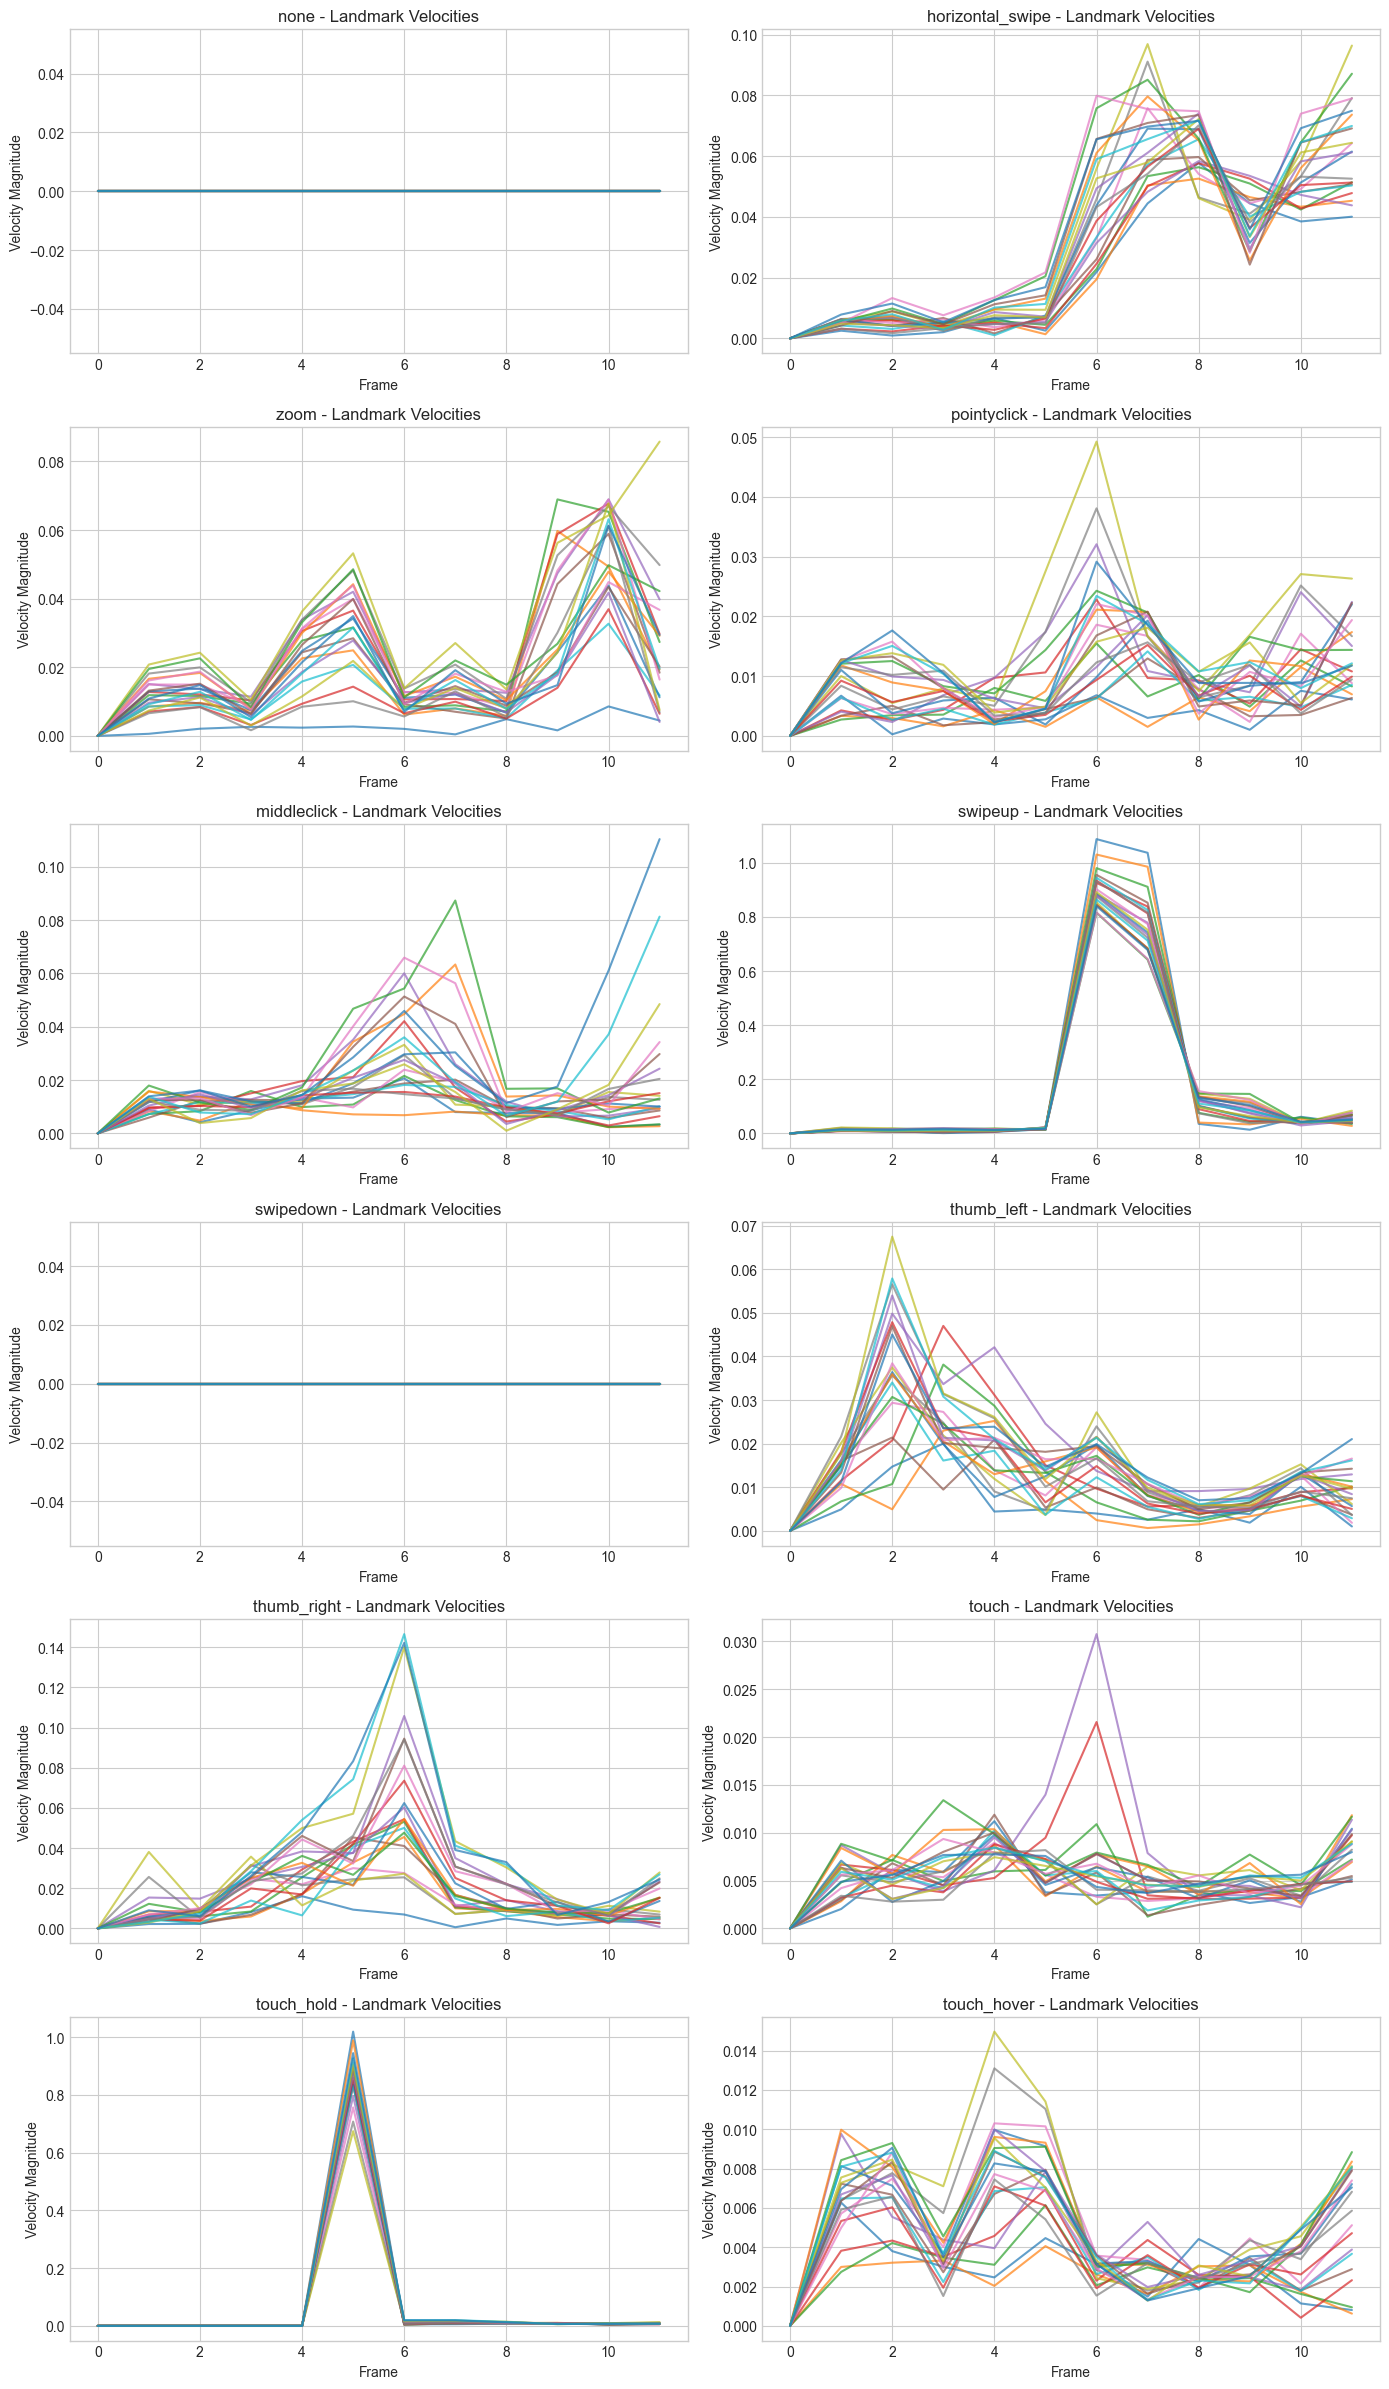

In [64]:
import math
import matplotlib.pyplot as plt
import numpy as np

# ---- dynamic layout ----
N = len(gesture_samples)
n_cols = 2
n_rows = math.ceil(N / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(7 * n_cols, 4 * n_rows),
    squeeze=False
)

axes = axes.flatten()

# ---- plot velocity curves ----
for idx, (gesture, seq) in enumerate(gesture_samples.items()):
    if seq is None:
        continue

    ax = axes[idx]

    T = seq.shape[0]  # number of frames

    # Compute per-frame velocity
    velocity = compute_velocity(seq)  # (T, 84)

    # Reshape to (frames, landmarks, xyz+visibility)
    velocity_xyz = velocity.reshape(T, 21, 4)[:, :, :3]

    # Compute magnitude for each landmark
    velocity_mag = np.linalg.norm(velocity_xyz, axis=2)  # (T, 21)

    # Plot each landmark as a line
    for landmark_idx in range(velocity_mag.shape[1]):
        ax.plot(
            range(T),
            velocity_mag[:, landmark_idx],
            alpha=0.7
        )

    ax.set_title(f"{gesture} - Landmark Velocities")
    ax.set_xlabel("Frame")
    ax.set_ylabel("Velocity Magnitude")
    ax.grid(True)

# ---- remove unused axes ----
for i in range(idx + 1, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()


## 2. Acceleration Features

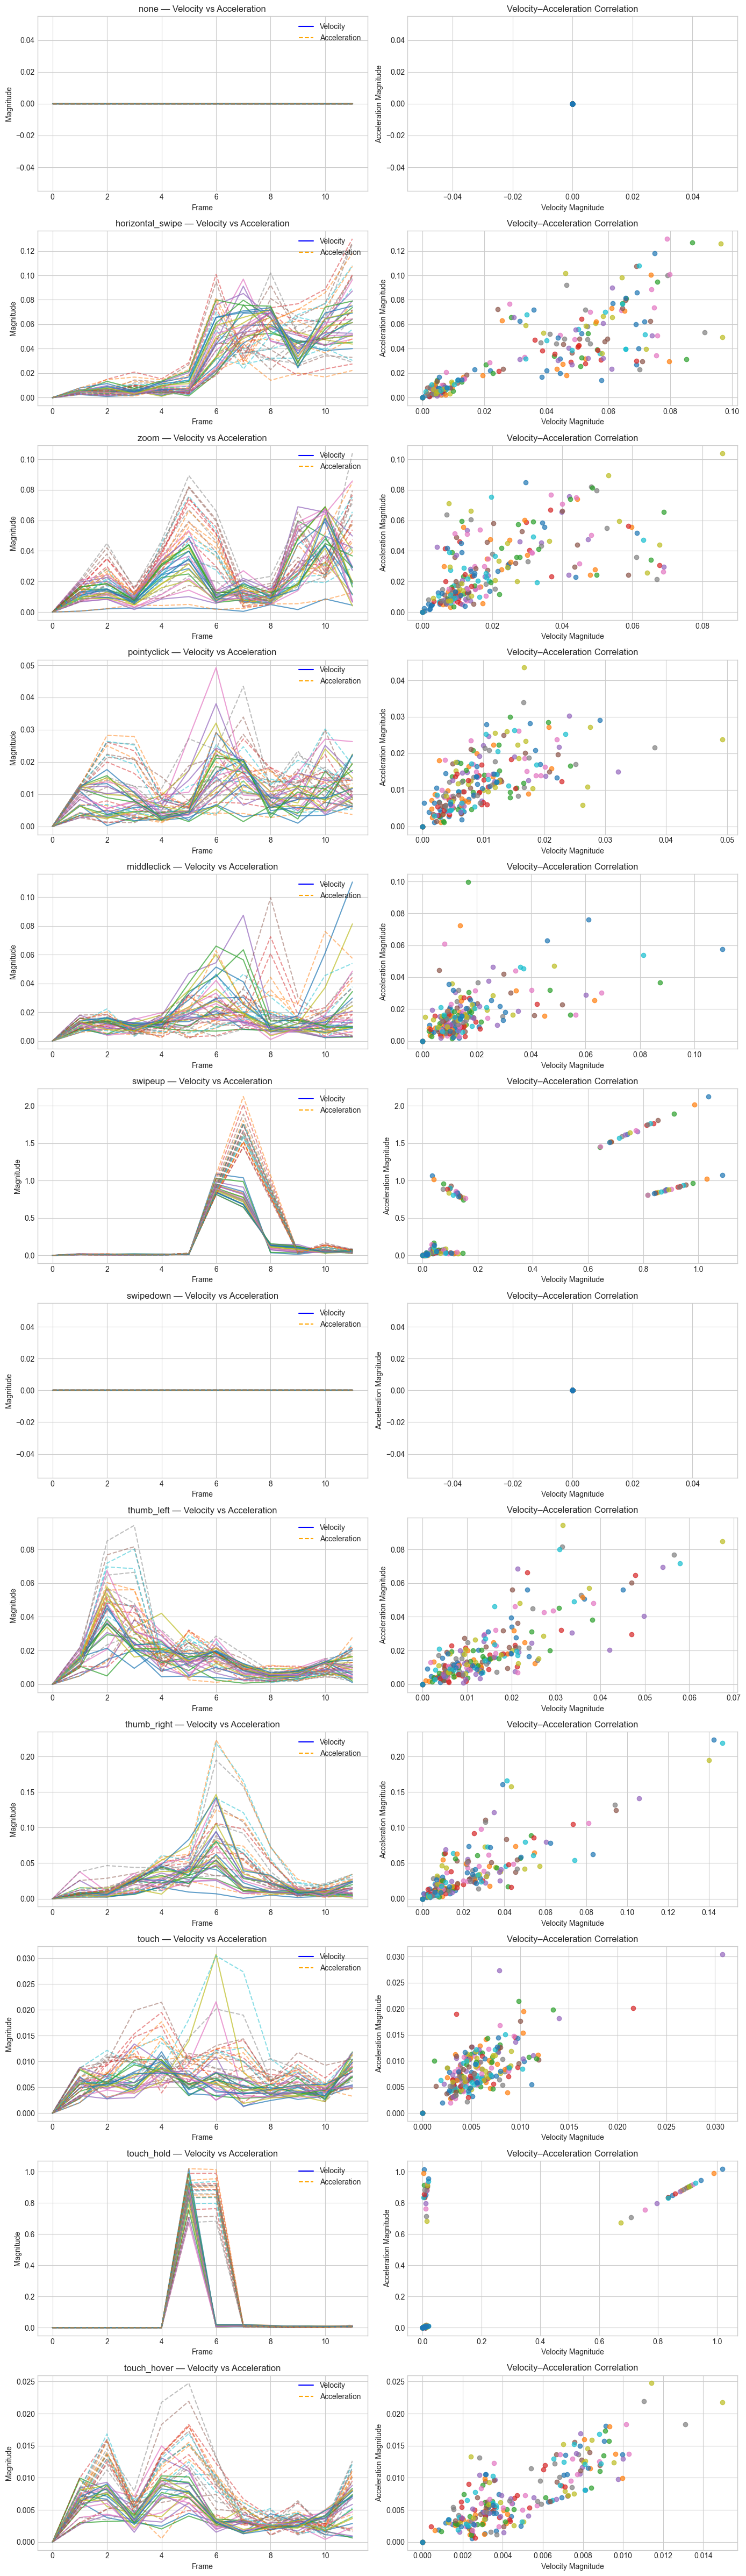

In [65]:
import math
import matplotlib.pyplot as plt
import numpy as np

def compute_acceleration(sequence):
    """
    Compute frame-to-frame acceleration (rate of velocity change).
    Returns:
        acceleration: (T, 84) array
    """
    velocity = compute_velocity(sequence)
    acceleration = np.diff(velocity, axis=0, prepend=velocity[0:1])
    return acceleration

# ---- filter valid gestures ----
valid_gestures = [(g, s) for g, s in gesture_samples.items() if s is not None]
N = len(valid_gestures)

fig, axes = plt.subplots(
    N,
    2,
    figsize=(14, 4 * N),
    squeeze=False
)

# ---- plotting ----
for row, (gesture, sample) in enumerate(valid_gestures):

    T = sample.shape[0]
    velocity = compute_velocity(sample)         # (T, 84)
    acceleration = compute_acceleration(sample) # (T, 84)

    # reshape: (frames, landmarks, xyz)
    velocity_xyz = velocity.reshape(T, 21, 4)[:, :, :3]
    acceleration_xyz = acceleration.reshape(T, 21, 4)[:, :, :3]

    # magnitude per landmark
    vel_mag = np.linalg.norm(velocity_xyz, axis=2)        # (T, 21)
    acc_mag = np.linalg.norm(acceleration_xyz, axis=2)   # (T, 21)

    # --- Time-series plot per landmark ---
    ax_ts = axes[row, 0]
    for landmark_idx in range(vel_mag.shape[1]):
        ax_ts.plot(range(T), vel_mag[:, landmark_idx], alpha=0.7)
        ax_ts.plot(range(T), acc_mag[:, landmark_idx], alpha=0.5, linestyle='--')

    ax_ts.set_xlabel('Frame')
    ax_ts.set_ylabel('Magnitude')
    ax_ts.set_title(f'{gesture} — Velocity vs Acceleration')
    ax_ts.grid(True)

    # optional: single legend
    ax_ts.plot([], [], color='blue', label='Velocity')
    ax_ts.plot([], [], color='orange', linestyle='--', label='Acceleration')
    ax_ts.legend(loc='upper right')

    # --- Scatter plot per landmark ---
    ax_scatter = axes[row, 1]
    for landmark_idx in range(vel_mag.shape[1]):
        ax_scatter.scatter(vel_mag[:, landmark_idx], acc_mag[:, landmark_idx], alpha=0.7)

    ax_scatter.set_xlabel('Velocity Magnitude')
    ax_scatter.set_ylabel('Acceleration Magnitude')
    ax_scatter.set_title('Velocity–Acceleration Correlation')
    ax_scatter.grid(True)

plt.tight_layout()
plt.show()


## 3. Finger Angle Features

In [ ]:
# SRC-COMPATIBLE: 5 finger angles (1 per finger at middle joint)
# This matches src/handflow/features/feature_engineer.py

def compute_finger_angles_src(sequence):
    """
    Compute bending angles for all 5 fingers (matches src implementation).
    Angle is computed at the middle joint (PIP for fingers, IP for thumb).
    
    Returns: 
        angles: (T, 5) where values are in radians
    """
    # Indices for joints [Proximal, Middle, Distal]
    joints = [
        (2, 3, 4),    # Thumb: CMC -> IP -> Tip
        (5, 6, 7),    # Index: MCP -> PIP -> DIP
        (9, 10, 11),  # Middle: MCP -> PIP -> DIP
        (13, 14, 15), # Ring: MCP -> PIP -> DIP
        (17, 18, 19)  # Pinky: MCP -> PIP -> DIP
    ]
    
    T = sequence.shape[0]
    angles = np.zeros((T, 5))
    
    for i, (a_idx, b_idx, c_idx) in enumerate(joints):
        # Extract points (T, 3)
        a = sequence[:, a_idx*4 : a_idx*4+3]
        b = sequence[:, b_idx*4 : b_idx*4+3]
        c = sequence[:, c_idx*4 : c_idx*4+3]
        
        # Vectors BA and BC
        ba = a - b
        bc = c - b
        
        # Compute angle
        norm_ba = np.linalg.norm(ba, axis=1, keepdims=True) + 1e-8
        norm_bc = np.linalg.norm(bc, axis=1, keepdims=True) + 1e-8
        
        dot_prod = np.sum(ba * bc, axis=1, keepdims=True) / (norm_ba * norm_bc)
        dot_prod = np.clip(dot_prod, -1.0, 1.0)
        
        angle_rad = np.arccos(dot_prod)
        angles[:, i] = angle_rad.flatten()
        
    return angles

# Test
sample_angles_src = compute_finger_angles_src(sequences[0])
print(f"SRC Angles shape: {sample_angles_src.shape}")
print(f"SRC Angle range (radians): [{sample_angles_src.min():.4f}, {sample_angles_src.max():.4f}]")
print(f"SRC Angle range (degrees): [{np.degrees(sample_angles_src.min()):.1f}, {np.degrees(sample_angles_src.max()):.1f}]")

In [72]:
# Finger joint indices for angle calculation
FINGER_JOINTS = [
    # Thumb
    (0, 1, 2), (1, 2, 3), (2, 3, 4),
    # Index
    (0, 5, 6), (5, 6, 7), (6, 7, 8),
    # Middle
    (0, 9, 10), (9, 10, 11), (10, 11, 12),
    # Ring
    (0, 13, 14), (13, 14, 15), (14, 15, 16),
    # Pinky
    (0, 17, 18), (17, 18, 19), (18, 19, 20),
]

def calculate_angle(p1, p2, p3):
    """
    Calculate angle at p2 formed by p1-p2-p3.
    
    Returns:
        angle in radians normalized to [0, 1]
    """
    v1 = p1 - p2
    v2 = p3 - p2
    
    cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-8)
    cos_angle = np.clip(cos_angle, -1.0, 1.0)
    angle = np.arccos(cos_angle)
    
    return angle / np.pi  # Normalize to [0, 1]

def compute_finger_angles(sequence):
    """
    Compute all 15 finger joint angles for each frame.
    
    Returns:
        angles: (16, 15) array
    """
    num_frames = sequence.shape[0]
    angles = np.zeros((num_frames, 15))
    
    for frame_idx in range(num_frames):
        landmarks = sequence[frame_idx].reshape(21, 4)[:, :3]  # x, y, z only
        
        for joint_idx, (p1, p2, p3) in enumerate(FINGER_JOINTS):
            angles[frame_idx, joint_idx] = calculate_angle(
                landmarks[p1], landmarks[p2], landmarks[p3]
            )
    
    return angles

# Test
sample_angles = compute_finger_angles(sequences[0])
print(f"Angles shape: {sample_angles.shape}")
print(f"Angle range: [{sample_angles.min():.4f}, {sample_angles.max():.4f}]")

Angles shape: (12, 15)
Angle range: [0.5000, 0.5000]


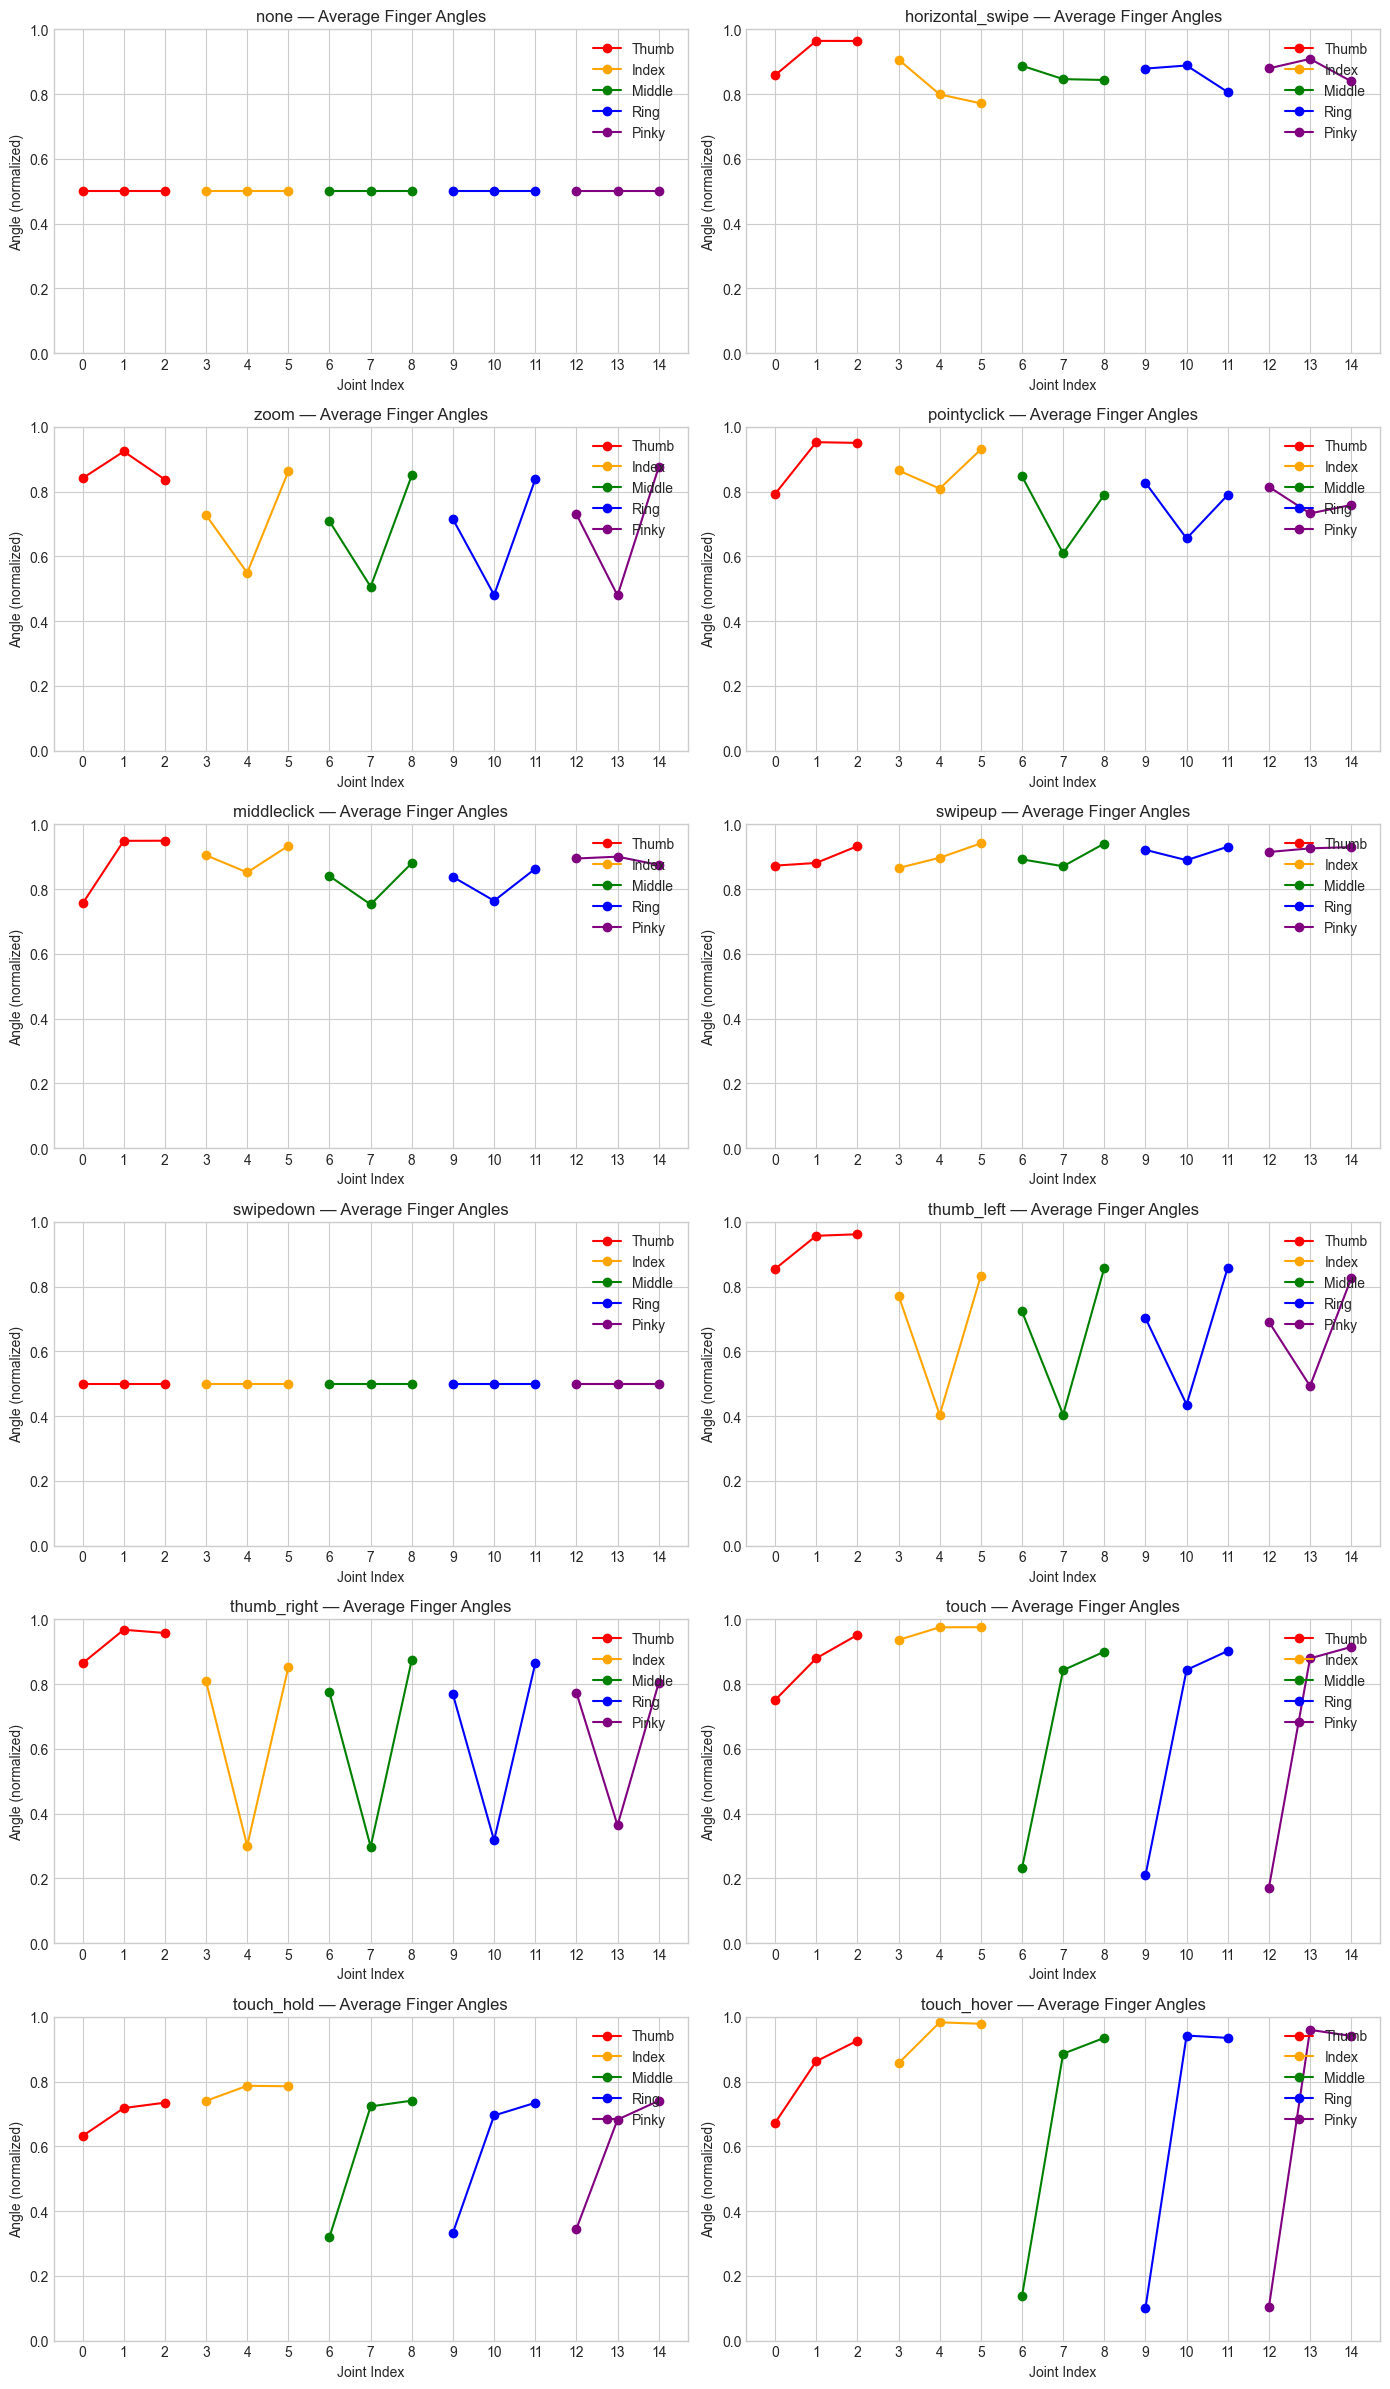

In [69]:
import math
import matplotlib.pyplot as plt
import numpy as np

# ---- filter valid gestures ----
valid_gestures = [(g, s) for g, s in gesture_samples.items() if s is not None]
N = len(valid_gestures)

n_cols = 2
n_rows = math.ceil(N / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(7 * n_cols, 4 * n_rows),
    squeeze=False
)
axes = axes.flatten()

# ---- constants ----
finger_names = ['Thumb', 'Index', 'Middle', 'Ring', 'Pinky']
joint_per_finger = 3

colors_map = {
    'Thumb': 'red',
    'Index': 'orange',
    'Middle': 'green',
    'Ring': 'blue',
    'Pinky': 'purple'
}

# ---- plotting ----
for idx, (gesture, seq) in enumerate(valid_gestures):
    ax = axes[idx]

    # Compute finger angles: shape (T, 15)
    angles = compute_finger_angles(seq)  

    # Average over frames
    avg_angles = angles.mean(axis=0)  # (15,)

    # Build colors per joint
    colors = []
    labels = []
    for i, finger in enumerate(finger_names):
        for j in range(joint_per_finger):
            colors.append(colors_map[finger])
            labels.append(finger)

    # Bar plot
    ax.bar(range(15), avg_angles, color=colors)
    ax.set_xlabel('Joint Index')
    ax.set_ylabel('Angle (normalized)')
    ax.set_title(f'{gesture} — Average Finger Angles')
    ax.set_ylim(0, 1)

    # Optional: label fingers on x-axis
    ax.set_xticks(range(15))
    ax.set_xticklabels(labels, rotation=45, ha='right')

# ---- remove unused axes ----
for i in range(idx + 1, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.savefig('../docs/finger_angles.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Hand Bounding Box Features

In [73]:
def compute_bbox_features(sequence):
    """
    Compute hand bounding box features.
    
    Features:
    - width: horizontal span
    - height: vertical span
    - area: width * height (indicates distance from camera)
    - aspect_ratio: width / height
    
    Returns:
        bbox_features: (16, 4) array
    """
    num_frames = sequence.shape[0]
    bbox_features = np.zeros((num_frames, 4))
    
    for frame_idx in range(num_frames):
        landmarks = sequence[frame_idx].reshape(21, 4)
        
        x_coords = landmarks[:, 0]
        y_coords = landmarks[:, 1]
        
        width = x_coords.max() - x_coords.min()
        height = y_coords.max() - y_coords.min()
        area = width * height
        aspect_ratio = width / (height + 1e-8)
        
        bbox_features[frame_idx] = [width, height, area, aspect_ratio]
    
    return bbox_features

# Test
sample_bbox = compute_bbox_features(sequences[0])
print(f"Bbox features shape: {sample_bbox.shape}")
print(f"Width range: [{sample_bbox[:, 0].min():.4f}, {sample_bbox[:, 0].max():.4f}]")

Bbox features shape: (12, 4)
Width range: [0.0000, 0.0000]


ValueError: number sections must be larger than 0.

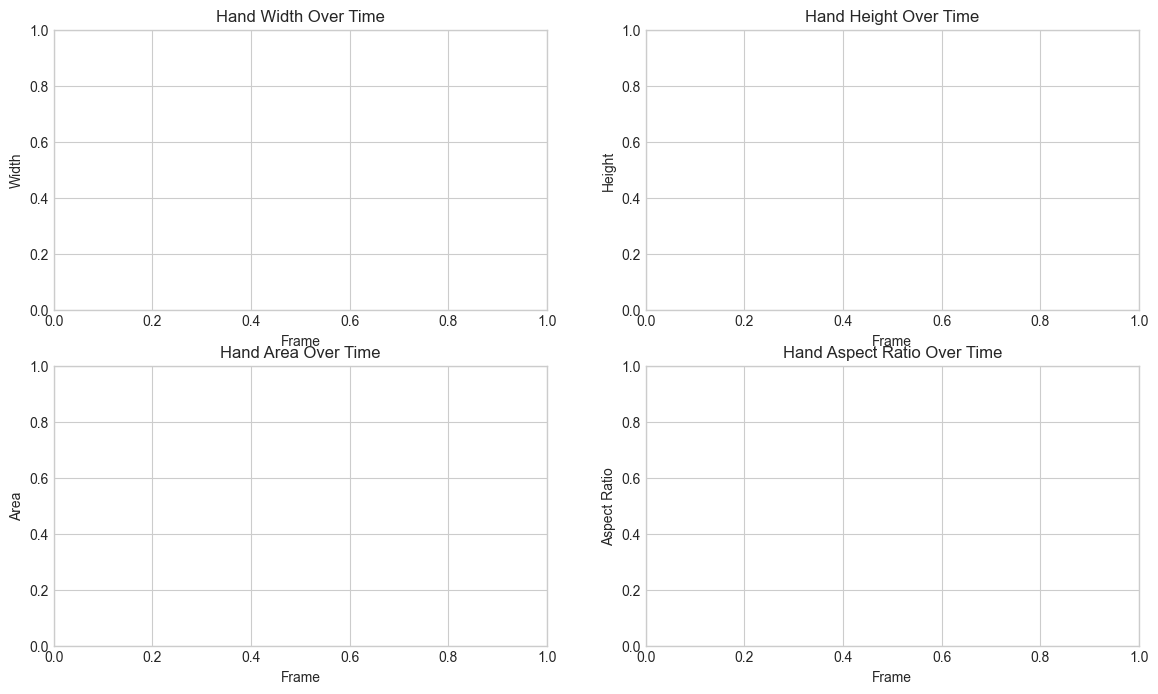

In [77]:
import matplotlib.pyplot as plt

# ---- layout: one subplot per bbox feature ----
feature_names = ['Width', 'Height', 'Area', 'Aspect Ratio']
n_features = len(feature_names)

n_cols = 2
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(7 * n_cols, 4 * n_rows),
    squeeze=False
)

axes = axes.flatten()

# ---- plot all gestures ----
for gesture, seq in gesture_samples.items():
    if seq is None:
        continue

    bbox = compute_bbox_features(seq)  # (T, 4)

    for feat_idx, feat_name in enumerate(feature_names):
        axes[feat_idx].plot(
            bbox[:, feat_idx],
            label=gesture,
            alpha=0.8
        )

# ---- axis formatting ----
for feat_idx, feat_name in enumerate(feature_names):
    ax = axes[feat_idx]
    ax.set_xlabel('Frame')
    ax.set_ylabel(feat_name)
    ax.set_title(f'Hand {feat_name} Over Time')

# ---- figure-level horizontal legend on top ----
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.05),
    ncol=len(labels),  # horizontal
    frameon=False      # optional: no box
)

# ---- remove unused axes ----
for i in range(n_features, len(axes)):
    fig.delaxes(axes[i])

# ---- layout and save ----
plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave space for legend
plt.savefig('../docs/bbox_features.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
def compute_inter_finger_distances(sequence):
    """
    Compute distances from thumb to all fingertips (matches src/handflow/features/feature_engineer.py).
    
    Pairs:
    - Thumb tip (4) to Index tip (8)
    - Thumb tip (4) to Middle tip (12)  
    - Thumb tip (4) to Ring tip (16)
    - Thumb tip (4) to Pinky tip (20)
    - Thumb tip (4) to Index PIP (6)

    Returns:
        distances: (T, 5)
    """
    num_frames = sequence.shape[0]
    distances = np.zeros((num_frames, 5))

    # Thumb to all fingertips + Index PIP (matches src)
    pairs = [(4, 8), (4, 12), (4, 16), (4, 20), (4, 6)]

    for i, (p1, p2) in enumerate(pairs):
        p1_coords = sequence[:, p1*4 : p1*4 + 3]
        p2_coords = sequence[:, p2*4 : p2*4 + 3]
        distances[:, i] = np.linalg.norm(p1_coords - p2_coords, axis=1)

    return distances

# Test
sample_dist = compute_inter_finger_distances(sequences[0])
print(f"Inter-finger distances shape: {sample_dist.shape}")
print(f"Distance range: [{sample_dist.min():.4f}, {sample_dist.max():.4f}]")

In [ ]:
import matplotlib.pyplot as plt

distance_names = [
    'Thumb-Index Tip',
    'Thumb-Middle Tip',
    'Thumb-Ring Tip',
    'Thumb-Pinky Tip',
    'Thumb-Index PIP'
]

n_features = len(distance_names)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(6 * n_cols, 4 * n_rows),
    squeeze=False
)

axes = axes.flatten()

# ---- plot all gestures ----
for gesture, seq in gesture_samples.items():
    if seq is None:
        continue

    distances = compute_inter_finger_distances(seq)  # (T, 5)

    for feat_idx, feat_name in enumerate(distance_names):
        axes[feat_idx].plot(
            distances[:, feat_idx],
            label=gesture,
            alpha=0.8
        )

# ---- formatting ----
for feat_idx, feat_name in enumerate(distance_names):
    ax = axes[feat_idx]
    ax.set_xlabel('Frame')
    ax.set_ylabel('Distance')
    ax.set_title(f'{feat_name} Distance Over Time')

# ---- figure-level legend ----
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=min(len(labels), 6),
    frameon=False
)

# ---- remove unused axes ----
for i in range(n_features, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('../docs/inter_finger_distances.png', dpi=150, bbox_inches='tight')
plt.show()

# 7. Finger curl (Fist/open detection) 

In [80]:
def compute_finger_curl(sequence):
    """
    Compute distance from finger tips to wrist (Landmark 0)
    """
    num_frames = sequence.shape[0]
    curls = np.zeros((num_frames, 5))

    tips = [4, 8, 12, 16, 20]
    wrist = sequence[:, 0:3] 
    
    for i, tip in enumerate(tips): 
        tip_coords = sequence[:, tip*4 : tip*4+3]
        curls[:, i] = np.linalg.norm(tip_coords - wrist, axis=1)
        
    return curls

/var/folders/3t/pzp15jbx0_739jd83sg_8scr0000gn/T/ipykernel_37098/2266566362.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


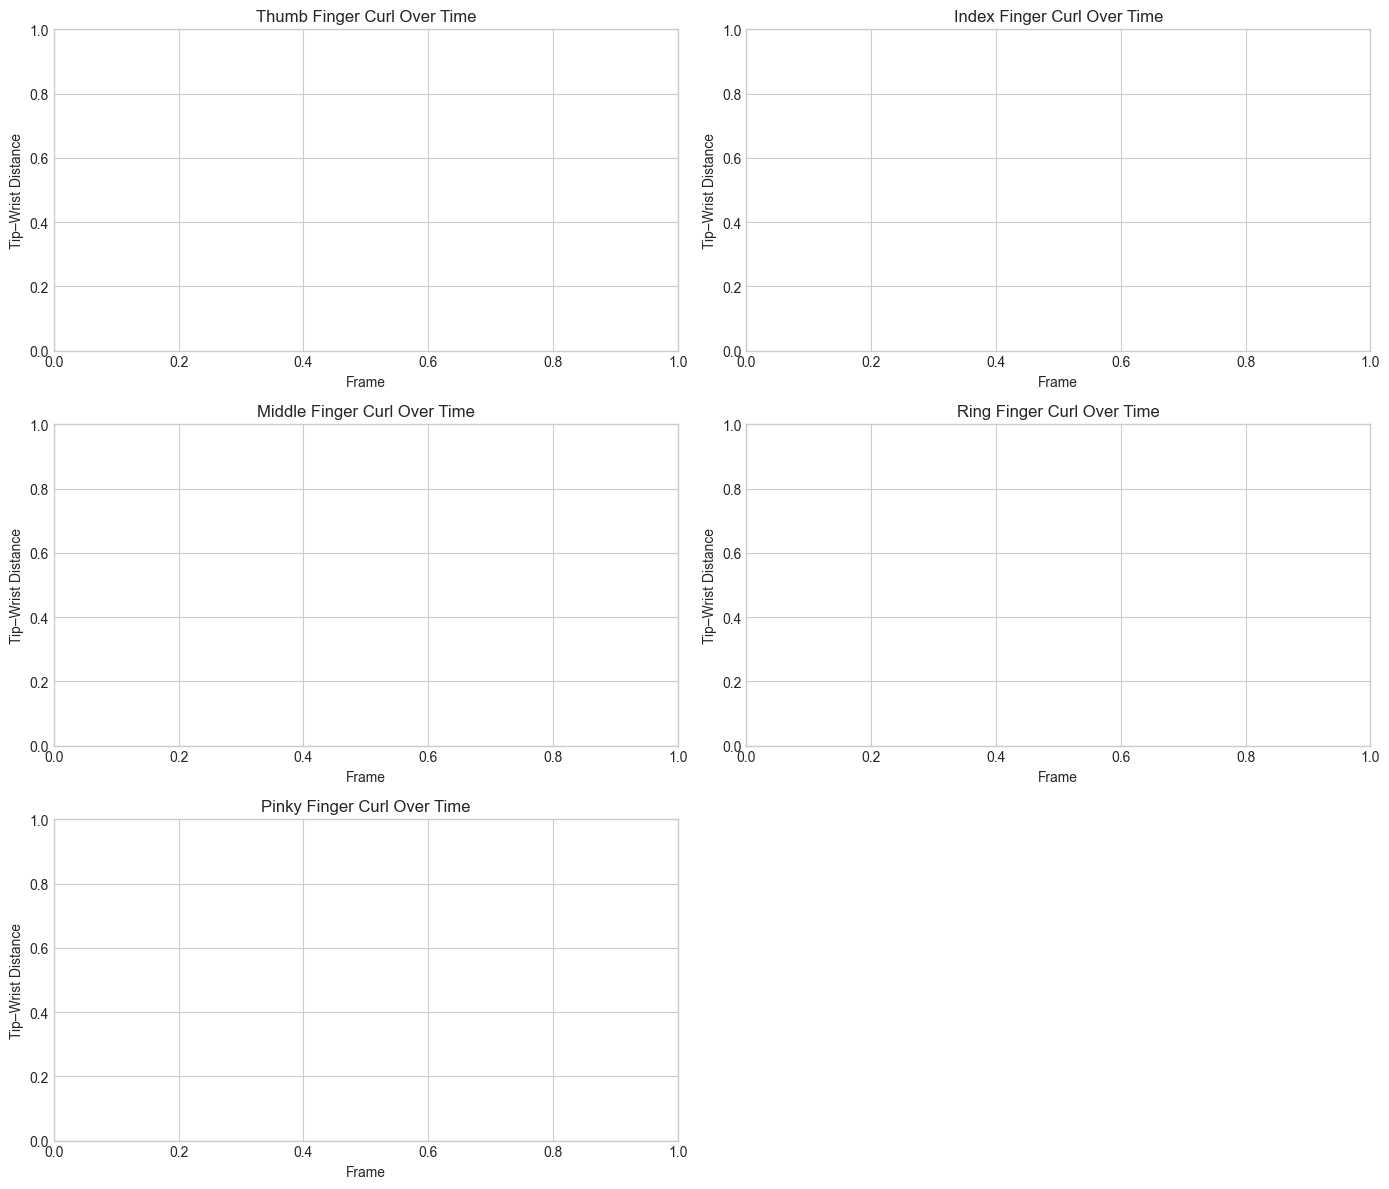

In [81]:
import matplotlib.pyplot as plt

finger_names = ['Thumb', 'Index', 'Middle', 'Ring', 'Pinky']
n_features = len(finger_names)

n_cols = 2
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(7 * n_cols, 4 * n_rows),
    squeeze=False
)

axes = axes.flatten()

# ---- plot all gestures ----
for gesture, seq in gesture_samples.items():
    if seq is None:
        continue

    curls = compute_finger_curl(seq)  # (T, 5)

    for feat_idx, finger in enumerate(finger_names):
        axes[feat_idx].plot(
            curls[:, feat_idx],
            label=gesture,
            alpha=0.8
        )

# ---- formatting ----
for feat_idx, finger in enumerate(finger_names):
    ax = axes[feat_idx]
    ax.set_xlabel('Frame')
    ax.set_ylabel('Tip–Wrist Distance')
    ax.set_title(f'{finger} Finger Curl Over Time')
    ax.legend()

# ---- remove unused axes ----
for i in range(n_features, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.savefig('../docs/finger_curl.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Palm orientation (palm normal)

In [43]:
def compute_palm_orientation(sequence: np.ndarray) -> np.ndarray:
    """
    Compute palm normal vector via cross product of:
    Wrist -> Index MCP  and  Wrist -> Pinky MCP.

    Args:
        sequence: np.ndarray of shape (T, 21*4)
                  Each landmark = (x, y, z, visibility)

    Returns:
        normals: np.ndarray of shape (T, 3)
    """
    wrist = sequence[:, 0:3]                     # Landmark 0
    index_mcp = sequence[:, 5*4 : 5*4 + 3]       # Landmark 5
    pinky_mcp = sequence[:, 17*4 : 17*4 + 3]     # Landmark 17

    v1 = index_mcp - wrist
    v2 = pinky_mcp - wrist

    cross = np.cross(v1, v2)
    norms = np.linalg.norm(cross, axis=1, keepdims=True)

    normals = cross / (norms + 1e-8)
    return normals


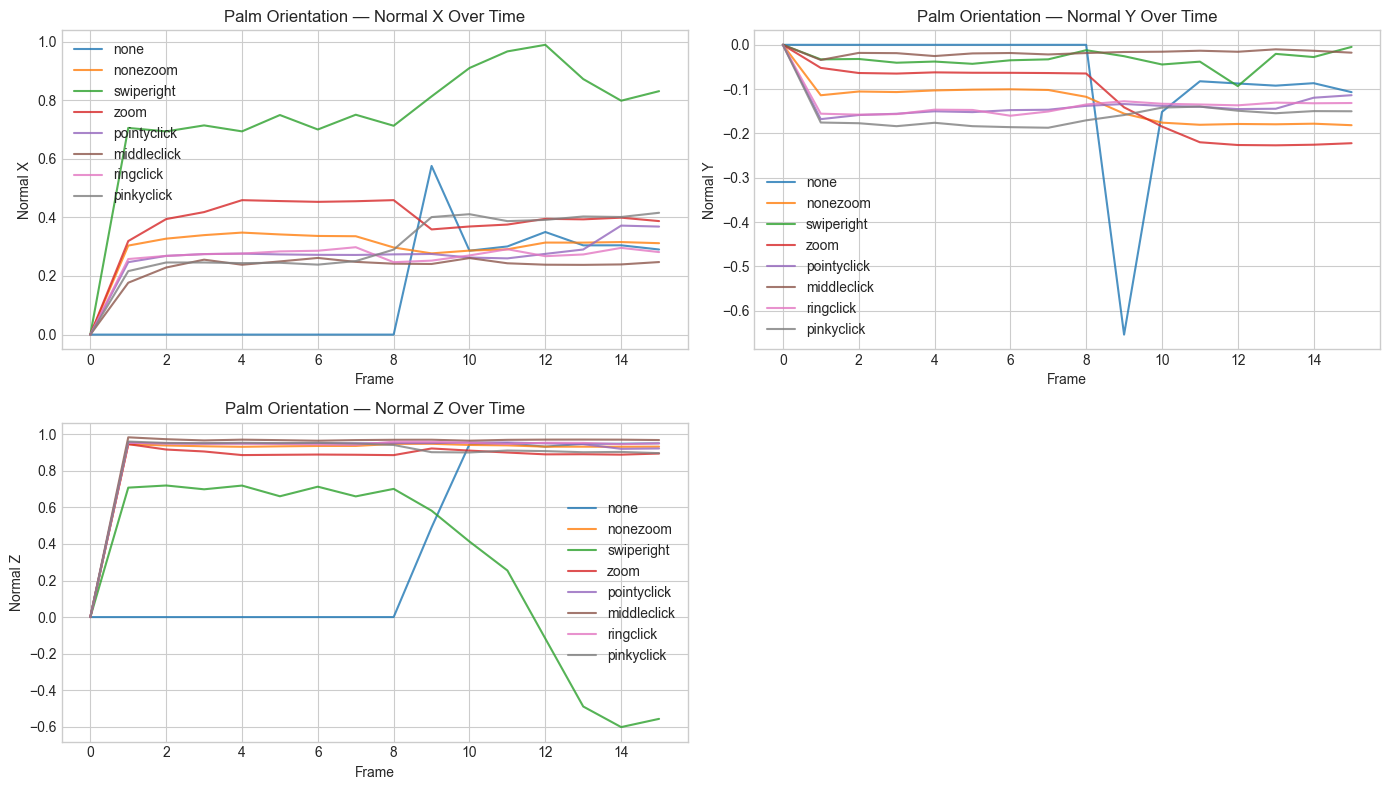

In [44]:
import matplotlib.pyplot as plt

component_names = ['Normal X', 'Normal Y', 'Normal Z']
n_features = len(component_names)

n_cols = 2
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(7 * n_cols, 4 * n_rows),
    squeeze=False
)

axes = axes.flatten()

# ---- plot all gestures ----
for gesture, seq in gesture_samples.items():
    if seq is None:
        continue

    normals = compute_palm_orientation(seq)  # (T, 3)

    for feat_idx, comp in enumerate(component_names):
        axes[feat_idx].plot(
            normals[:, feat_idx],
            label=gesture,
            alpha=0.8
        )

# ---- formatting ----
for feat_idx, comp in enumerate(component_names):
    ax = axes[feat_idx]
    ax.set_xlabel('Frame')
    ax.set_ylabel(comp)
    ax.set_title(f'Palm Orientation — {comp} Over Time')
    ax.legend()

# ---- remove unused axes ----
for i in range(n_features, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.savefig('../docs/palm_orientation.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Feature Importance Visualization with PCA

In [33]:
# Apply feature engineering to all data
print("🔧 Applying feature engineering...")
transformed_sequences = np.array([engineer.transform(seq) for seq in sequences])
print(f"   Shape: {transformed_sequences.shape}")

# Flatten to (n_samples, n_features)
X = transformed_sequences.reshape(len(sequences), -1)
print(f"   Flattened: {X.shape}")

🔧 Applying feature engineering...
   Shape: (350, 16, 271)
   Flattened: (350, 4336)


In [34]:
# PCA for dimensionality visualization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total explained: {pca.explained_variance_ratio_.sum():.2%}")

Explained variance ratio: [0.15970549 0.0921216 ]
Total explained: 25.18%


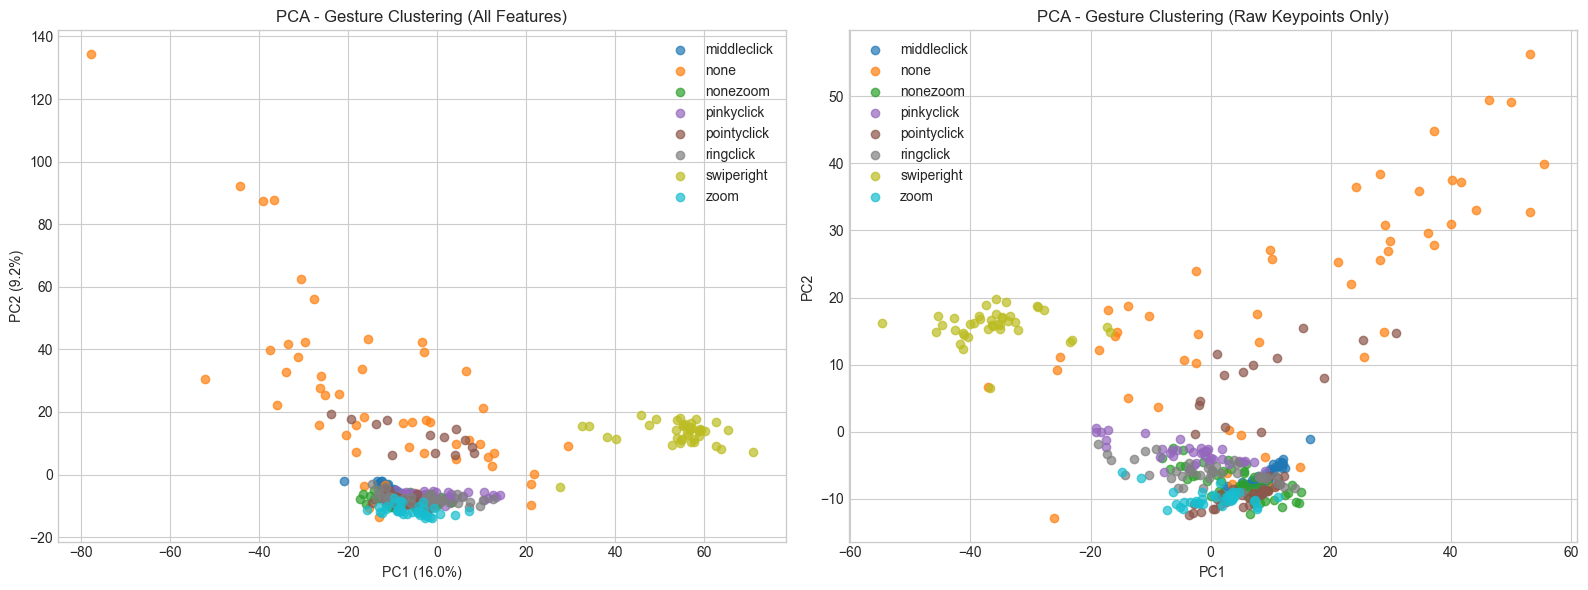

In [35]:
# Visualize PCA
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA scatter
unique_labels = np.unique(labels)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

for label, color in zip(unique_labels, colors):
    mask = labels == label
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], c=[color], label=label, alpha=0.7)

axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[0].set_title('PCA - Gesture Clustering (All Features)')
axes[0].legend()

# Compare with raw features only
X_raw = sequences.reshape(len(sequences), -1)
X_raw_scaled = StandardScaler().fit_transform(X_raw)
X_raw_pca = PCA(n_components=2).fit_transform(X_raw_scaled)

for label, color in zip(unique_labels, colors):
    mask = labels == label
    axes[1].scatter(X_raw_pca[mask, 0], X_raw_pca[mask, 1], c=[color], label=label, alpha=0.7)

axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('PCA - Gesture Clustering (Raw Keypoints Only)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../docs/pca_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Summary & Recommendations

In [ ]:
print("="*60)
print("📋 FEATURE ENGINEERING SUMMARY")
print("="*60)
print()
print("📊 FEATURE DIMENSIONS:")
print(f"   Base keypoints: 84 (21 landmarks × 4)")
print(f"   With all features: {engineer.get_output_dim()}")
print()
print("🔍 FEATURE IMPACT:")
print("   • Velocity: Critical for swipe detection")
print("   • Acceleration: Helps with motion dynamics")
print("   • Finger angles: Distinguishes click types")
print("   • Bbox size: Distance/zoom awareness")
print()
print("💡 RECOMMENDATIONS:")
print("   1. Enable all features initially")
print("   2. Model will learn which are important")
print("   3. Can prune later if needed for speed")
print("   4. Consider feature selection if overfitting")
print("="*60)

## Next Steps

Continue to:
- **04_model_exploration.ipynb** - Train and compare different model architectures